Original col_list: ['_RFHLTH', '_HCVU651', '_RFHYPE5', '_CHOLCHK', '_RFCHOL', '_MICHD', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_PRACE1', '_MRACE1', '_HISPANC', '_RACE', '_RACEG21', '_RACEGR3', '_RACE_G1', '_AGEG5YR', '_AGE65YR', '_AGE80', '_AGE_G', '_HTIN4', '_HTM4', '_WTKG3', '_BMI5', '_BMI5CAT', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_SMOKER3', '_RFSMOK3', '_DRNKANY5', '_DROCDY3_', '_RFBING5', '_DRNKWEK', '_RFDRHV5', '_FTJUDA1_', '_FRUTDA1_', '_BEANDAY_', '_GRENDAY_', '_ORNGDAY_', '_VEGEDA1_', '_MISFRTN', '_MISVEGN', '_FRTRESP', '_VEGRESP', '_FRUTSUM', '_VEGESUM', '_FRTLT1', '_VEGLT1', '_FRT16', '_VEG23', '_FRUITEX', '_VEGETEX', '_TOTINDA', '_METVL11_', '_METVL21_', '_MAXVO2_', '_FC60_', '_ACTIN11_', '_ACTIN21_', '_PADUR1_', '_PADUR2_', '_PAFREQ1_', '_PAFREQ2_', '_MINAC11_', '_MINAC21_', '_STRFREQ_', '_PAMISS1_', '_PAMIN11_', '_PAMIN21_', '_PA1MIN_', '_PAVIG11_', '_PAVIG21_', '_PA1VIGM_', '_PACAT1_', '_PAINDX1_', '_PA150R2_', '_PA300R2_', '_PA30021_', '_PASTRNG_', '_

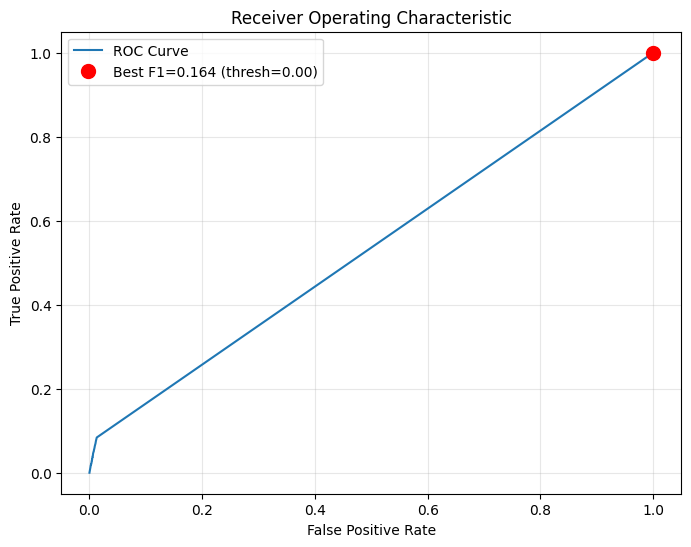

Best F1 Score: 0.1638 at threshold 0.00
TPR: 1.0000, FPR: 1.0000
New Best F1 Score: 0.1638 at threshold 0.00
Training with lr=0.1, alpha=0.1, class_weight_1=20.0


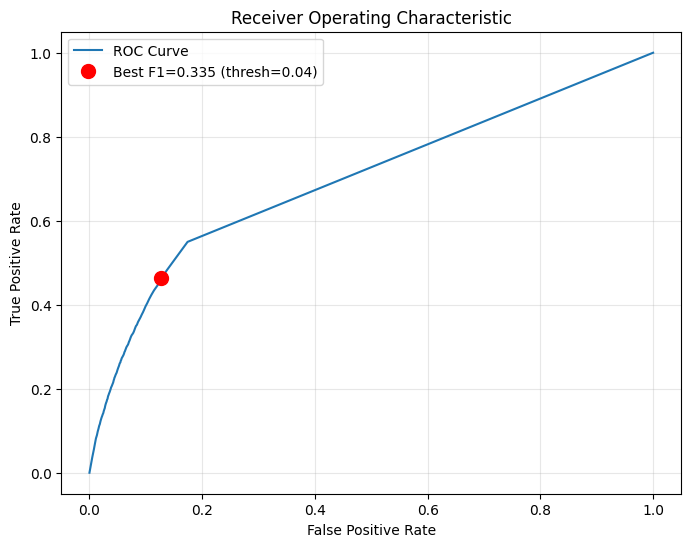

Best F1 Score: 0.3347 at threshold 0.04
TPR: 0.4632, FPR: 0.1277
New Best F1 Score: 0.3347 at threshold 0.04
Training with lr=0.1, alpha=0.1, class_weight_1=30.0


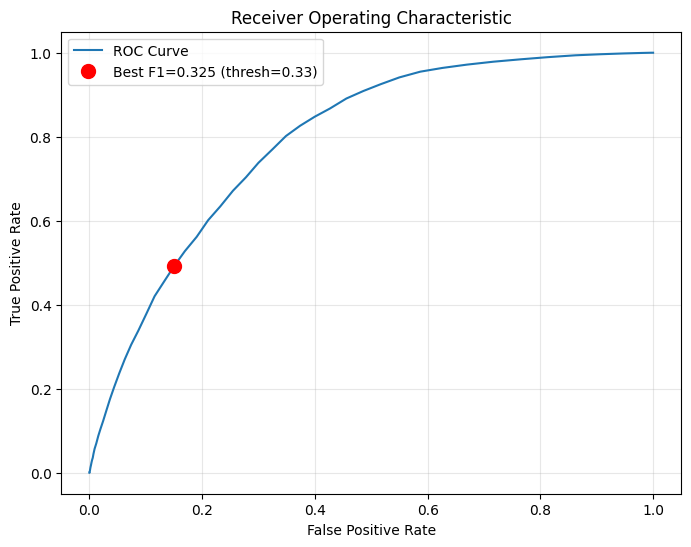

Best F1 Score: 0.3252 at threshold 0.33
TPR: 0.4924, FPR: 0.1504
Training with lr=0.1, alpha=0.01, class_weight_1=10.0


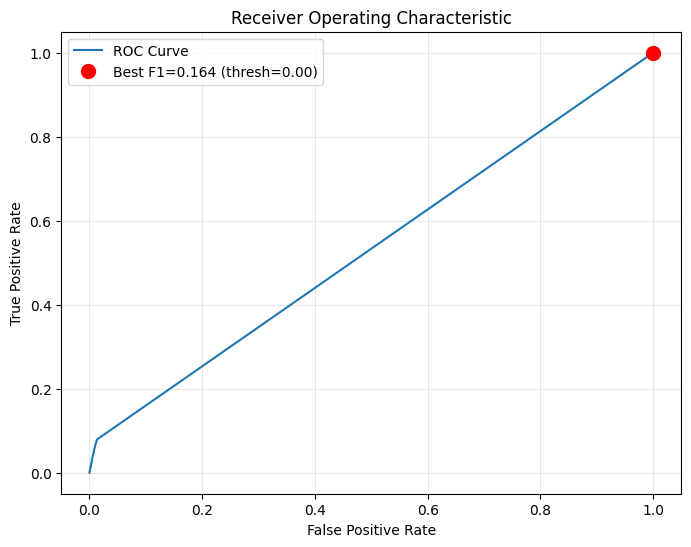

Best F1 Score: 0.1638 at threshold 0.00
TPR: 1.0000, FPR: 1.0000
Training with lr=0.1, alpha=0.01, class_weight_1=20.0


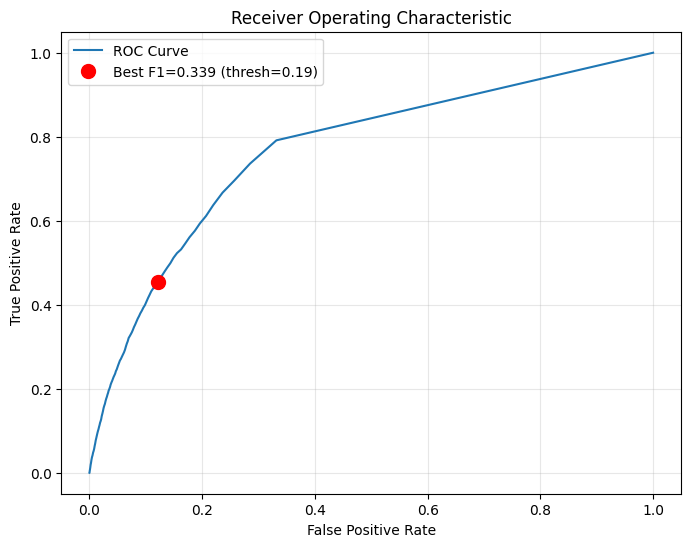

Best F1 Score: 0.3386 at threshold 0.19
TPR: 0.4552, FPR: 0.1207
New Best F1 Score: 0.3386 at threshold 0.19
Training with lr=0.1, alpha=0.01, class_weight_1=30.0


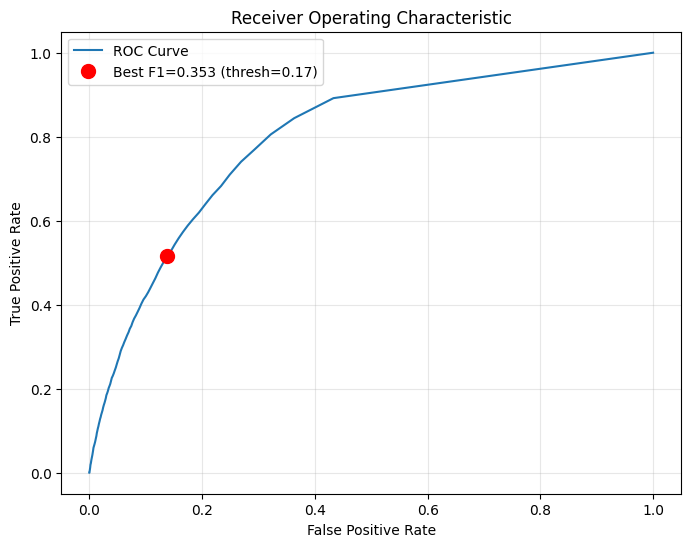

Best F1 Score: 0.3528 at threshold 0.17
TPR: 0.5155, FPR: 0.1377
New Best F1 Score: 0.3528 at threshold 0.17
Training with lr=0.1, alpha=0.001, class_weight_1=10.0


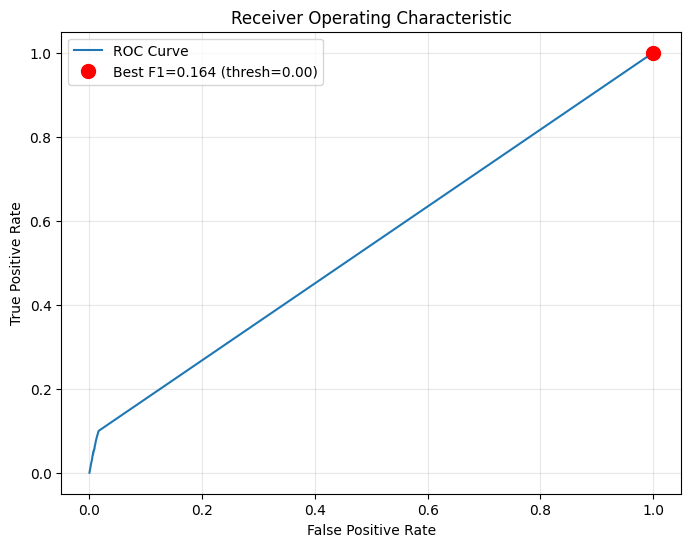

Best F1 Score: 0.1638 at threshold 0.00
TPR: 1.0000, FPR: 1.0000
Training with lr=0.1, alpha=0.001, class_weight_1=20.0


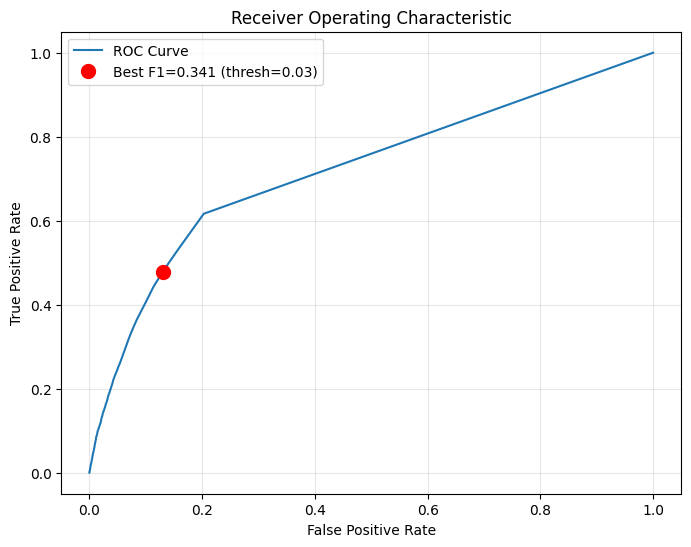

Best F1 Score: 0.3413 at threshold 0.03
TPR: 0.4780, FPR: 0.1296
Training with lr=0.1, alpha=0.001, class_weight_1=30.0


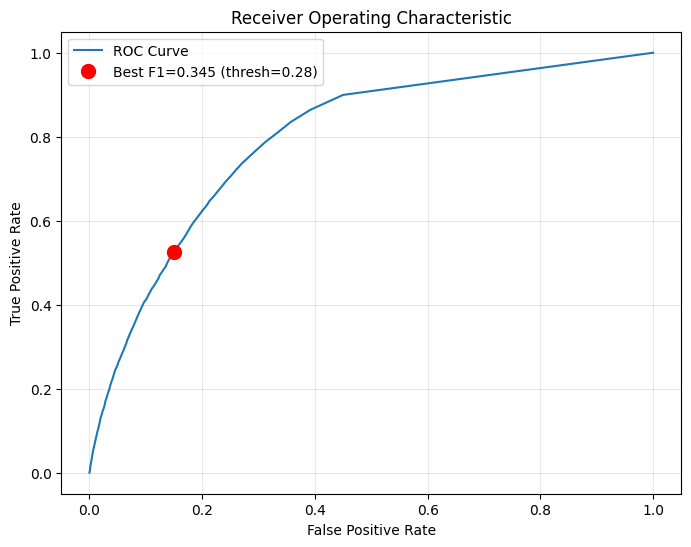

Best F1 Score: 0.3447 at threshold 0.28
TPR: 0.5264, FPR: 0.1496
Training with lr=0.01, alpha=0.1, class_weight_1=10.0


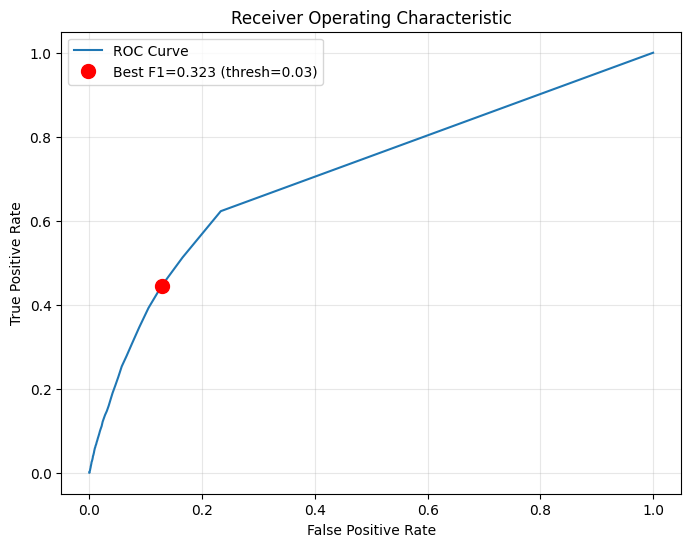

Best F1 Score: 0.3232 at threshold 0.03
TPR: 0.4446, FPR: 0.1279
Training with lr=0.01, alpha=0.1, class_weight_1=20.0


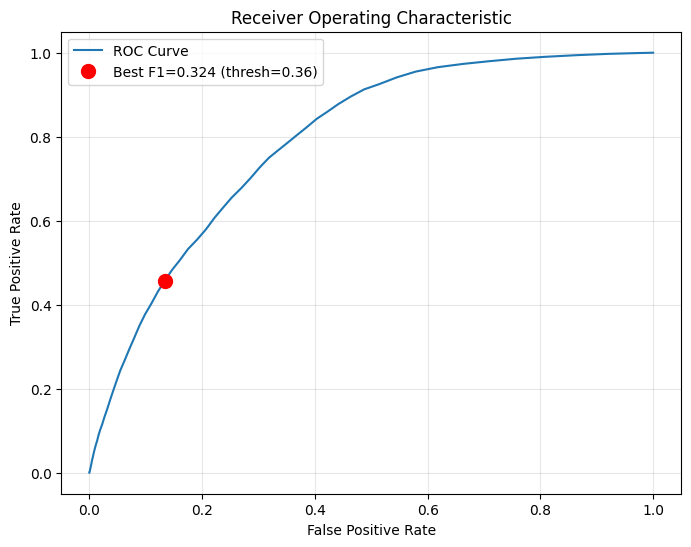

Best F1 Score: 0.3242 at threshold 0.36
TPR: 0.4567, FPR: 0.1333
Training with lr=0.01, alpha=0.1, class_weight_1=30.0


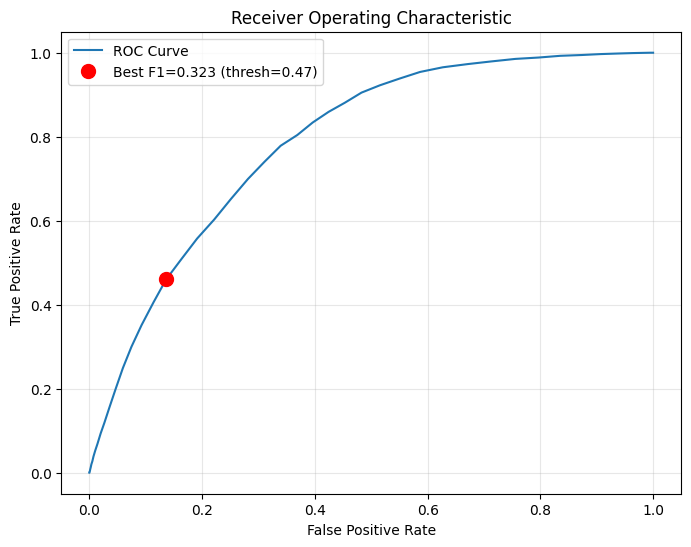

Best F1 Score: 0.3230 at threshold 0.47
TPR: 0.4603, FPR: 0.1361
Training with lr=0.01, alpha=0.01, class_weight_1=10.0


KeyboardInterrupt: 

In [1]:
#import libraries
import numpy as np
from helper import *#import helper functions
import list as lt
%load_ext autoreload
%aimport helper, list  
%autoreload 1

#grid search for hyperparameters, returns at the end the best model found
best_f1_overall = 0
best_thresh_overall = 0
best_col_list = None
best_lr = 0
best_alpha = 0
best_class_weight_1 = 0
for col_list in [lt.col_list, lt.col_list_2, lt.col_list_3]:
    header = load_header('../data/dataset/x_test.csv')
    x_train_expanded, expanded_col_names = expand_dataset_col(col_list, '../data/dataset/x_train.csv')
    x_train_full = x_train_expanded#load_data_column('x_train_expanded.csv', column_list=None)
    y_train_full = load_data_col('../data/dataset/y_train.csv', cols=(1))
    x_train,y_train,x_test,y_test = split_data_train_test_80(x_train_full, y_train_full, seed=1)
    for  lr in [0.1, 0.01, 0.001]:
        for alpha in [0.1, 0.01, 0.001]:
            for class_weight_1 in [10.0, 20.0, 30.0]:
                print(f"Training with col_list={col_list}, lr={lr}, alpha={alpha}, class_weight_1={class_weight_1}")
                model = LogisticRegression_costum(
                    lr=lr,
                    max_iter=1000,
                    penalty="elasticnet",
                    alpha=alpha,
                    class_weight={-1: 1.0, 1: class_weight_1},
                    bias_init=0.5,
                    verbose=False,
                    early_stopping=True,
                    method='stochastic',
                    patience=20
                )
                model.fit(x_train, y_train, x_test, y_test)
                y_pred = model.predict(x_test, threshold=0.5)
                temp_f1, temp_thresh = model.roc_curve(x_test, y_test)
                if temp_f1 > best_f1_overall:
                    best_f1_overall = temp_f1
                    best_thresh_overall = temp_thresh
                    best_col_list = col_list
                    best_lr = lr
                    best_alpha = alpha
                    best_class_weight_1 = class_weight_1
                    print(f"New Best F1 Score: {best_f1_overall:.4f} at threshold {best_thresh_overall:.2f}")
